In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re

# Add vllm_exp to path to import log analyzing tools
sys.path.insert(0, '/home/bxb1/vllm_workbench/vllm/vllm_exp')
from log_analysing_tools.analyze_log_metrics import LogMetricsAnalyzer, METRIC_CONFIGS

print("Libraries imported successfully!")

# ==================== CONFIGURATION ====================
# Define log directories - set to None if not used
# If only one log_dir is defined, single mode will be used
# If both are defined, comparison mode will be used

log_dir_0 = Path('/home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}')
log_dir_1 = Path('/home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=1000}-{mig_mode=async}') # Set to None for single mode, or provide a path for comparison mode
# log_dir_1 = Path('/home/bxb1/vllm_workbench/vllm/logs/project-migration_cmp_heter/test-{flexi=0}-{pp=36-28}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}')
# =======================================================

# Validate log directories
def validate_log_dir(log_dir, name="log_dir"):
    """Check if a log directory is valid"""
    if log_dir is None:
        return False, f"{name} is not defined (None)"
    if not isinstance(log_dir, Path):
        log_dir = Path(log_dir)
    if not log_dir.exists():
        return False, f"{name} does not exist: {log_dir}"
    return True, f"{name} is valid: {log_dir}"

valid_0, msg_0 = validate_log_dir(log_dir_0, "log_dir_0")
valid_1, msg_1 = validate_log_dir(log_dir_1, "log_dir_1")

print(msg_0)
print(msg_1)

# Determine mode
if valid_0 and valid_1:
    MODE = "comparison"
    print(f"\n✓ Mode: COMPARISON (comparing two log directories)")
    log_dirs = {'dir_0': log_dir_0, 'dir_1': log_dir_1}
    labels = {'dir_0': 'Config 0', 'dir_1': 'Config 1'}
elif valid_0:
    MODE = "single"
    print(f"\n✓ Mode: SINGLE (analyzing one log directory)")
    log_dirs = {'dir_0': log_dir_0}
    labels = {'dir_0': log_dir_0.name}
elif valid_1:
    MODE = "single"
    print(f"\n✓ Mode: SINGLE (analyzing one log directory)")
    log_dirs = {'dir_0': log_dir_1}  # Use dir_1 as the single source
    labels = {'dir_0': log_dir_1.name}
else:
    MODE = "error"
    print(f"\n✗ ERROR: No valid log directories defined!")
    print("Please define at least one valid log_dir_0 or log_dir_1")
    log_dirs = {}
    labels = {}

# Set primary log_dir for saving outputs
if log_dirs:
    log_dir = list(log_dirs.values())[0].parent if MODE == "single" else list(log_dirs.values())[0].parent
    print(f"\nOutput directory: {log_dir}")

# Analyze server.log files
analyzers = {}

if MODE != "error":
    for key, dir_path in log_dirs.items():
        log_file = dir_path / 'server.log'
        print(f"\nAnalyzing {labels[key]}: {log_file}")
        
        if log_file.exists():
            analyzer = LogMetricsAnalyzer(str(log_file))
            analyzer.analyze_file()
            analyzers[key] = analyzer
            print(f"  ✓ Analysis complete!")
        else:
            print(f"  ✗ server.log not found!")
            analyzers[key] = None

    # Check if we have any valid analyzers
    valid_analyzers = {k: v for k, v in analyzers.items() if v is not None}
    if not valid_analyzers:
        print("\n✗ ERROR: No valid server.log files found!")
        MODE = "error"
    else:
        print(f"\n✓ Successfully analyzed {len(valid_analyzers)} log file(s)")

# Function to extract average time in microseconds from a list of time strings
def calculate_avg_time_us(time_strings):
    """Parse time strings and return average in microseconds"""
    if not time_strings:
        return 0
    
    times_us = []
    for time_str in time_strings:
        time_str = time_str.strip()
        match = re.match(r'([0-9.eE+-]+)\s*(µs|ms|seconds?|s)', time_str)
        if match:
            value = float(match.group(1))
            unit = match.group(2)
            
            if unit in ['µs']:
                time_us = value
            elif unit == 'ms':
                time_us = value * 1000
            elif unit in ['seconds', 'second', 's']:
                time_us = value * 1000000
            else:
                time_us = value
            
            times_us.append(time_us)
    
    return sum(times_us) / len(times_us) if times_us else 0

# Collect metrics from analyzers
metrics_data = {}

if MODE != "error":
    for config in METRIC_CONFIGS:
        metric_name = config.name
        display_name = config.display_name
        
        metric_entry = {}
        has_data = False
        
        for key, analyzer in analyzers.items():
            if analyzer is None:
                metric_entry[key] = {'avg': 0, 'count': 0, 'raw': None}
                continue
                
            data = analyzer.metrics.get(metric_name)
            
            if config.metric_type.value == "keyed_dict":
                all_values = []
                if data:
                    for layer_id, values in data.items():
                        all_values.extend(values)
                avg = calculate_avg_time_us(all_values)
                count = len(all_values)
            else:
                avg = calculate_avg_time_us(data if data else [])
                count = len(data) if isinstance(data, list) else 0
            
            metric_entry[key] = {'avg': avg, 'count': count, 'raw': data}
            if avg > 0:
                has_data = True
        
        if has_data:
            metrics_data[display_name] = metric_entry
    
    print(f"\nFound {len(metrics_data)} metrics with data")
    
    # Show sample metrics
    print("\nSample metrics:")
    for i, (name, data) in enumerate(list(metrics_data.items())[:5]):
        if MODE == "comparison":
            print(f"  {name}: dir_0={data.get('dir_0', {}).get('avg', 0):.2f}µs, dir_1={data.get('dir_1', {}).get('avg', 0):.2f}µs")
        else:
            print(f"  {name}: {data.get('dir_0', {}).get('avg', 0):.2f}µs (count={data.get('dir_0', {}).get('count', 0)})")

# For comparison mode, filter metrics with both
if MODE == "comparison":
    metrics_with_both = {k: v for k, v in metrics_data.items() 
                         if v.get('dir_0', {}).get('avg', 0) > 0 and v.get('dir_1', {}).get('avg', 0) > 0}
    print(f"\nMetrics with data in both configs: {len(metrics_with_both)}")
    
    if metrics_with_both:
        comparison_df = pd.DataFrame({
            'Metric': list(metrics_with_both.keys()),
            'Config 0 (µs)': [v['dir_0']['avg'] for v in metrics_with_both.values()],
            'Config 1 (µs)': [v['dir_1']['avg'] for v in metrics_with_both.values()],
            'Count_0': [v['dir_0']['count'] for v in metrics_with_both.values()],
            'Count_1': [v['dir_1']['count'] for v in metrics_with_both.values()]
        })
        comparison_df['Change (%)'] = ((comparison_df['Config 1 (µs)'] - comparison_df['Config 0 (µs)']) / 
                                        comparison_df['Config 0 (µs)'] * 100)
        comparison_df = comparison_df.sort_values('Change (%)', key=abs, ascending=False)
        print("\nTop 10 metrics with largest relative changes:")
        print(comparison_df.head(10)[['Metric', 'Config 0 (µs)', 'Config 1 (µs)', 'Change (%)']].to_string(index=False))
else:
    metrics_with_both = {}
    comparison_df = None
    
    # For single mode, create a simple dataframe
    if MODE == "single" and metrics_data:
        single_df = pd.DataFrame({
            'Metric': list(metrics_data.keys()),
            'Avg Time (µs)': [v['dir_0']['avg'] for v in metrics_data.values()],
            'Count': [v['dir_0']['count'] for v in metrics_data.values()]
        })
        single_df = single_df.sort_values('Avg Time (µs)', ascending=False)
        print("\nTop 10 metrics by average time:")
        print(single_df.head(10).to_string(index=False))

Libraries imported successfully!
log_dir_0 is valid: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}
log_dir_1 is valid: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=1000}-{mig_mode=async}

✓ Mode: COMPARISON (comparing two log directories)

Output directory: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test

Analyzing Config 0: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}/server.log
Analyzing log file: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}/server.log
Finished parsing log file.


Plot saved to: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/metrics_comparison.png


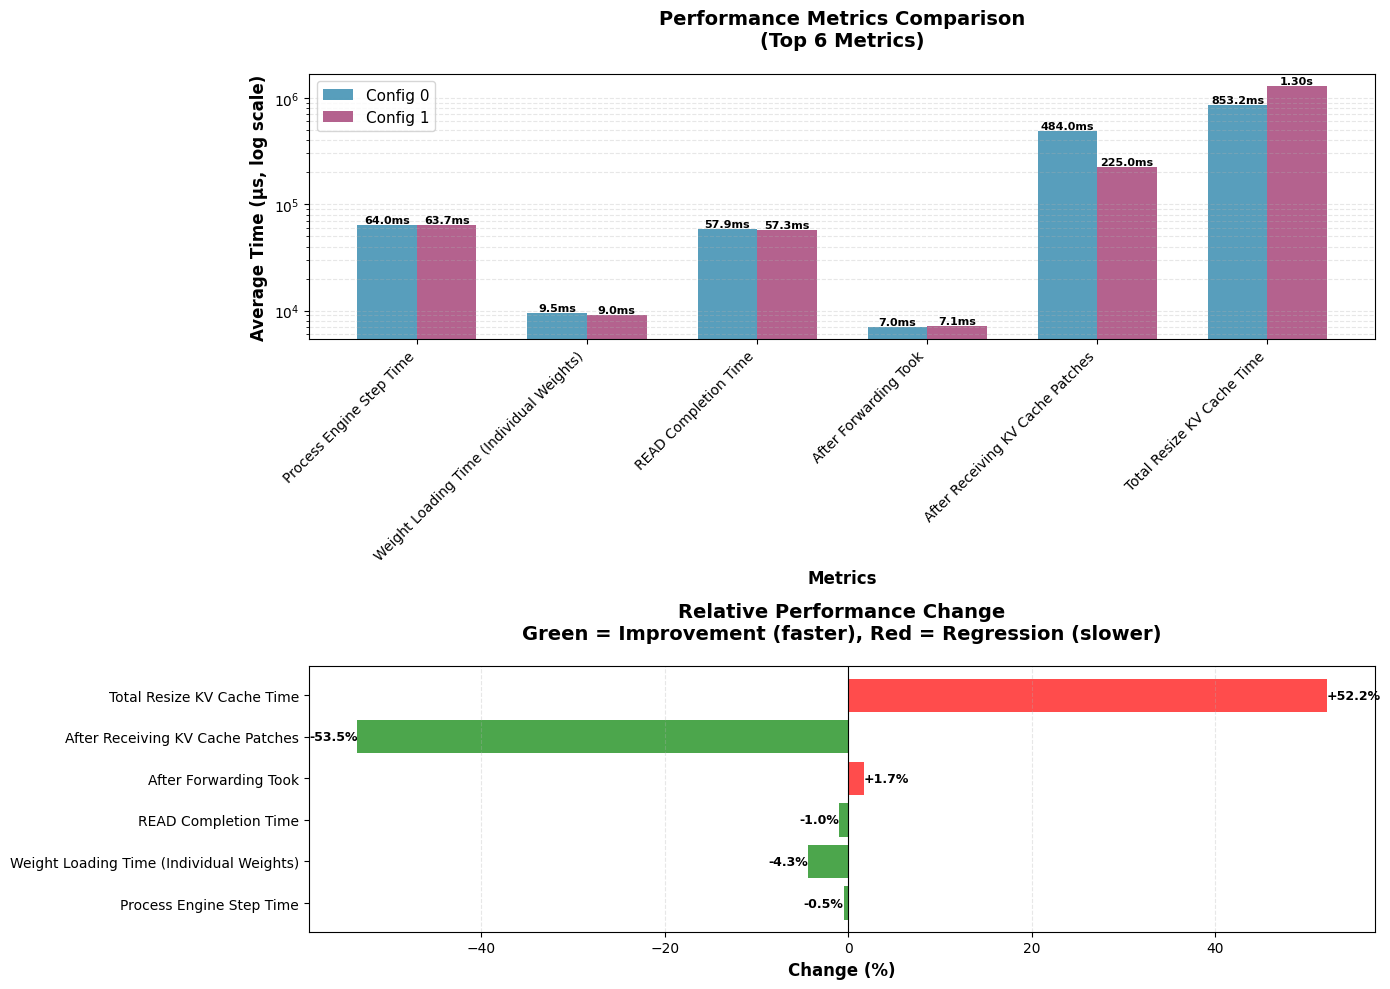

In [2]:
# Create the main bar chart (comparison or single mode)
Top_Metrics = 6

if MODE == "error":
    print("Cannot create plots - no valid log directories!")
elif MODE == "comparison" and len(metrics_with_both) > 0:
    # === COMPARISON MODE ===
    priority_metrics = [
        'Compact KV Cache Times (Within Lock)',
        'Process Engine Step Time',
        'Weight Loading Time (Individual Weights)',
        '[CompiledDAG] READ Completion Time',
        'After Forwarding Took'
    ]
    
    priority_rows = []
    other_rows = []
    
    for idx, row in comparison_df.iterrows():
        if row['Metric'] in priority_metrics:
            priority_rows.append(row)
        else:
            other_rows.append(row)
    
    if priority_rows:
        priority_df = pd.DataFrame(priority_rows)
        priority_df['priority_order'] = priority_df['Metric'].apply(
            lambda x: priority_metrics.index(x) if x in priority_metrics else 999
        )
        priority_df = priority_df.sort_values('priority_order').drop('priority_order', axis=1)
    else:
        priority_df = pd.DataFrame()
    
    if other_rows:
        other_df = pd.DataFrame(other_rows)
        other_df = other_df.sort_values('Change (%)', key=abs, ascending=False)
    else:
        other_df = pd.DataFrame()
    
    if not priority_df.empty and not other_df.empty:
        remaining_slots = max(0, Top_Metrics - len(priority_df))
        plot_df = pd.concat([priority_df, other_df.head(remaining_slots)], ignore_index=True)
    elif not priority_df.empty:
        plot_df = priority_df.head(Top_Metrics)
    else:
        plot_df = other_df.head(Top_Metrics)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    x = np.arange(len(plot_df))
    width = 0.35
    
    short_names = [name.split(']')[-1].strip() if ']' in name else name[:40] 
                   for name in plot_df['Metric']]
    
    bars1 = ax1.bar(x - width/2, plot_df['Config 0 (µs)'], width, 
                    label=labels.get('dir_0', 'Config 0'), alpha=0.8, color='#2E86AB')
    bars2 = ax1.bar(x + width/2, plot_df['Config 1 (µs)'], width, 
                    label=labels.get('dir_1', 'Config 1'), alpha=0.8, color='#A23B72')
    
    ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Average Time (µs, log scale)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Performance Metrics Comparison\n(Top {Top_Metrics} Metrics)', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(short_names, rotation=45, ha='right', fontsize=10)
    ax1.legend(fontsize=11)
    ax1.set_yscale('log')
    ax1.grid(axis='y', alpha=0.3, linestyle='--', which='both')
    
    def add_value_labels(ax, bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                if height >= 1000000:
                    label = f'{height/1000000:.2f}s'
                elif height >= 1000:
                    label = f'{height/1000:.1f}ms'
                else:
                    label = f'{height:.0f}µs'
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       label, ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    add_value_labels(ax1, bars1)
    add_value_labels(ax1, bars2)
    
    colors = ['green' if x < 0 else 'red' for x in plot_df['Change (%)']]
    bars3 = ax2.barh(range(len(plot_df)), plot_df['Change (%)'], color=colors, alpha=0.7)
    
    ax2.set_yticks(range(len(plot_df)))
    ax2.set_yticklabels(short_names, fontsize=10)
    ax2.set_xlabel('Change (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Relative Performance Change\nGreen = Improvement (faster), Red = Regression (slower)', 
                  fontsize=14, fontweight='bold', pad=20)
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    
    for i, (idx, row) in enumerate(plot_df.iterrows()):
        change = row['Change (%)']
        label = f'{change:+.1f}%'
        ax2.text(change, i, label, ha='left' if change > 0 else 'right', 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    save_path = log_dir / 'metrics_comparison.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {save_path}")
    plt.show()

elif MODE == "single" and metrics_data:
    # === SINGLE MODE ===
    priority_metrics = [
        'Compact KV Cache Times (Within Lock)',
        'Process Engine Step Time',
        'Weight Loading Time (Individual Weights)',
        '[CompiledDAG] READ Completion Time',
        'After Forwarding Took'
    ]
    
    # Sort metrics by average time
    sorted_metrics = sorted(metrics_data.items(), key=lambda x: x[1]['dir_0']['avg'], reverse=True)
    
    # Prioritize specific metrics
    priority_items = [(k, v) for k, v in sorted_metrics if k in priority_metrics]
    other_items = [(k, v) for k, v in sorted_metrics if k not in priority_metrics]
    
    remaining_slots = max(0, Top_Metrics - len(priority_items))
    display_items = priority_items + other_items[:remaining_slots]
    display_items = display_items[:Top_Metrics]
    
    if display_items:
        metric_names = [item[0] for item in display_items]
        metric_values = [item[1]['dir_0']['avg'] for item in display_items]
        metric_counts = [item[1]['dir_0']['count'] for item in display_items]
        
        short_names = [name.split(']')[-1].strip() if ']' in name else name[:40] 
                       for name in metric_names]
        
        fig, ax = plt.subplots(figsize=(14, 8))
        
        x = np.arange(len(display_items))
        bars = ax.bar(x, metric_values, alpha=0.8, color='#2E86AB')
        
        ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
        ax.set_ylabel('Average Time (µs, log scale)', fontsize=12, fontweight='bold')
        ax.set_title(f'Performance Metrics - {labels.get("dir_0", "Single Config")}\n(Top {Top_Metrics} Metrics)', 
                     fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=10)
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3, linestyle='--', which='both')
        
        # Add value labels
        for bar, count in zip(bars, metric_counts):
            height = bar.get_height()
            if height > 0:
                if height >= 1000000:
                    label = f'{height/1000000:.2f}s\n(n={count})'
                elif height >= 1000:
                    label = f'{height/1000:.1f}ms\n(n={count})'
                else:
                    label = f'{height:.0f}µs\n(n={count})'
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       label, ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        plt.tight_layout()
        save_path = log_dir / 'metrics_single.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {save_path}")
        plt.show()
    else:
        print("No metrics to display!")
else:
    print("No metrics data available to plot!")

Loading Config 0: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}/request_metrics.csv
  ✓ Loaded 200 requests
Loading Config 1: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/test-{kernel=direct}-{pp=24-40}-{rr=5}-{mig=1}-{in=64}-{out=64}-{n_req=200}-{rep=1}-{chunk=1000}-{mig_mode=async}/request_metrics.csv
  ✓ Loaded 200 requests

Time series plot saved to: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/request_metrics_time_series.png


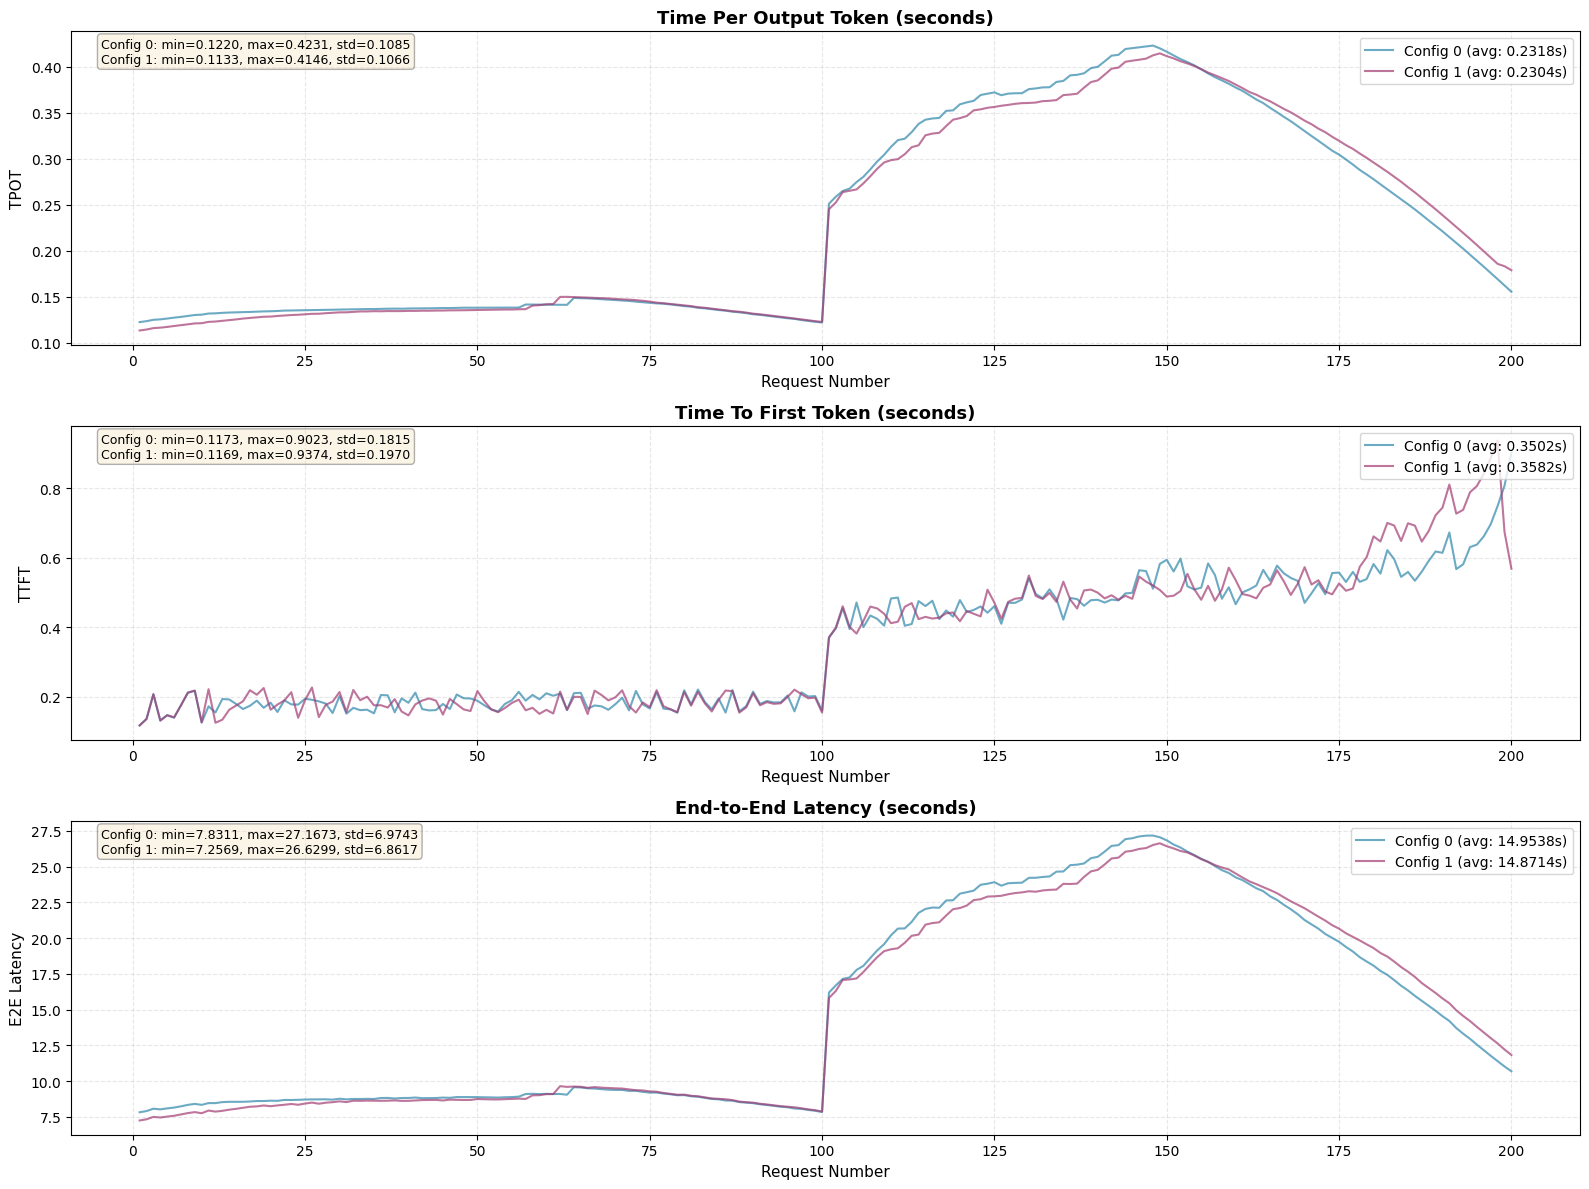


SUMMARY STATISTICS

TPOT:
  Config 0: mean=0.231803s, median=0.152098s
  Config 1: mean=0.230368s, median=0.164375s
  Change: -0.62%

TTFT:
  Config 0: mean=0.350211s, median=0.295734s
  Config 1: mean=0.358191s, median=0.297948s
  Change: +2.28%

E2E Latency:
  Config 0: mean=14.953810s, median=10.138326s
  Config 1: mean=14.871362s, median=10.745314s
  Change: -0.55%


In [3]:
# Load time series data from request metrics CSV files
import pandas as pd

if MODE == "error":
    print("Cannot load request metrics - no valid log directories!")
else:
    # Load CSV files based on mode
    csv_files = {}
    dfs = {}
    
    for key, dir_path in log_dirs.items():
        csv_path = dir_path / 'request_metrics.csv'
        print(f"Loading {labels[key]}: {csv_path}")
        
        if csv_path.exists():
            csv_files[key] = csv_path
            dfs[key] = pd.read_csv(csv_path)
            dfs[key]['request_index'] = range(1, len(dfs[key]) + 1)
            print(f"  ✓ Loaded {len(dfs[key])} requests")
        else:
            print(f"  ✗ File not found!")
    
    if not dfs:
        print("\nERROR: No request_metrics.csv files found!")
    else:
        # Metric configurations for plotting
        metrics = [
            ('tpots', 'Time Per Output Token (seconds)', 'TPOT'),
            ('ttfts', 'Time To First Token (seconds)', 'TTFT'),
            ('e2els', 'End-to-End Latency (seconds)', 'E2E Latency')
        ]
        
        colors_flexi = ['#2E86AB', '#A23B72']
        
        fig, axes = plt.subplots(3, 1, figsize=(16, 12))
        
        for idx, (metric_col, title, ylabel) in enumerate(metrics):
            ax = axes[idx]
            
            for i, (key, df) in enumerate(dfs.items()):
                if metric_col in df.columns:
                    avg_val = df[metric_col].mean()
                    ax.plot(df['request_index'], df[metric_col], 
                            label=f'{labels[key]} (avg: {avg_val:.4f}s)',
                            color=colors_flexi[i % len(colors_flexi)], alpha=0.7, linewidth=1.5)
            
            ax.set_xlabel('Request Number', fontsize=11)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(title, fontsize=13, fontweight='bold')
            ax.legend(loc='upper right', fontsize=10)
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Add statistics text box
            stats_lines = []
            for key, df in dfs.items():
                if metric_col in df.columns:
                    stats_lines.append(f'{labels[key]}: min={df[metric_col].min():.4f}, max={df[metric_col].max():.4f}, std={df[metric_col].std():.4f}')
            
            if stats_lines:
                ax.text(0.02, 0.98, '\n'.join(stats_lines), transform=ax.transAxes, 
                        fontsize=9, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        plt.tight_layout()
        save_path = log_dir / 'request_metrics_time_series.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'\nTime series plot saved to: {save_path}')
        plt.show()
        
        # Print summary statistics
        print('\n' + '='*80)
        print('SUMMARY STATISTICS')
        print('='*80)
        for metric_col, _, ylabel in metrics:
            print(f'\n{ylabel}:')
            for key, df in dfs.items():
                if metric_col in df.columns:
                    print(f'  {labels[key]}: mean={df[metric_col].mean():.6f}s, median={df[metric_col].median():.6f}s')
            
            # Calculate change if comparison mode
            if MODE == "comparison" and len(dfs) == 2:
                keys = list(dfs.keys())
                if metric_col in dfs[keys[0]].columns and metric_col in dfs[keys[1]].columns:
                    val_0 = dfs[keys[0]][metric_col].mean()
                    val_1 = dfs[keys[1]][metric_col].mean()
                    if val_0 > 0:
                        change = ((val_1 - val_0) / val_0) * 100
                        print(f'  Change: {change:+.2f}%')

Process Engine Step Time:
  Config 0: 1691 data points
  Config 1: 1683 data points
After Forwarding Took:
  Config 0: 1688 data points
  Config 1: 1680 data points
Communication Time from Upstream:
  Config 0: 844 data points
  Config 1: 839 data points
[Ray.Comm.Read] Tensors Received Time:
  Config 0: 844 data points
  Config 1: 840 data points
[RAY.NCCLGROUP.Read] Recv Buffer Allocation Time:
  Config 0: 1688 data points
  Config 1: 1680 data points
[RAY.NCCLGROUP.Read] Received Data From Comm Time:
  Config 0: 1688 data points
  Config 1: 1680 data points

Extracted time series data for 6 metrics

Time series plot saved to: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test/analysis_metrics_time_series.png


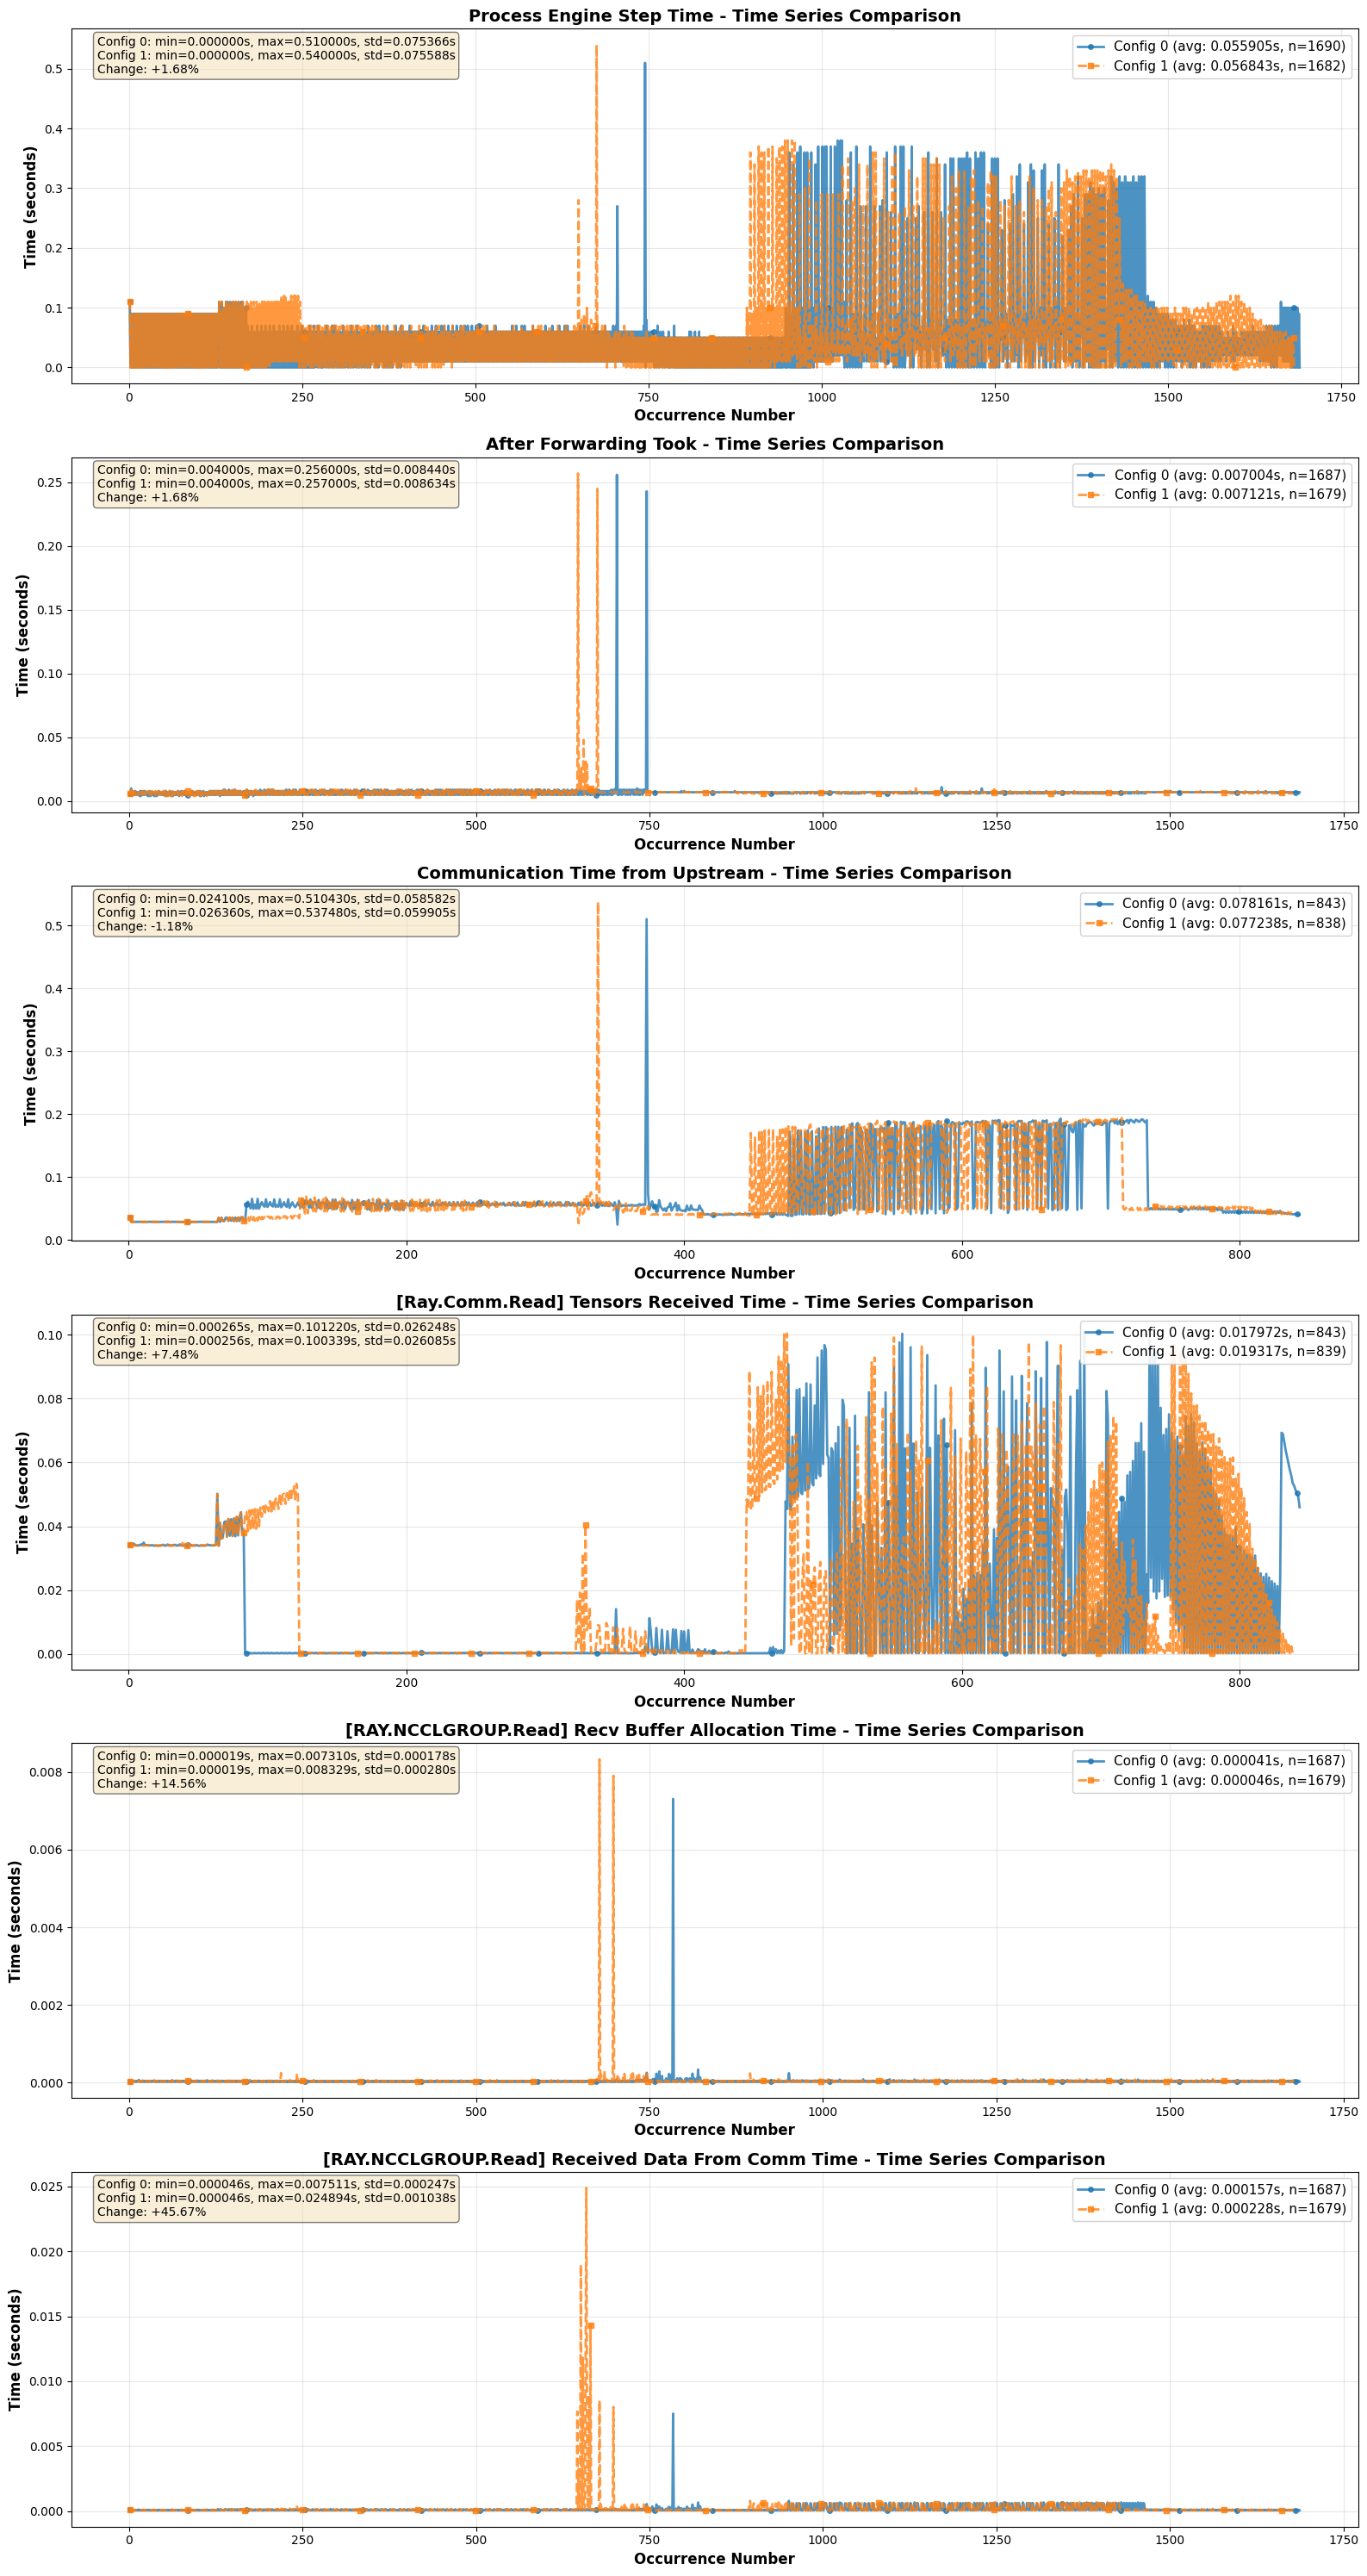


DETAILED STATISTICS FOR ANALYSIS LOG METRICS

Process Engine Step Time:
  Config 0: mean=0.064027s, median=0.050000s, min=0.000000s, max=13.790000s
  Config 1: mean=0.063714s, median=0.050000s, min=0.000000s, max=11.620000s
  Mean change: -0.49%

After Forwarding Took:
  Config 0: mean=0.007003s, median=0.007000s, min=0.004000s, max=0.256000s
  Config 1: mean=0.007120s, median=0.007000s, min=0.004000s, max=0.257000s
  Mean change: +1.67%

Communication Time from Upstream:
  Config 0: mean=0.078113s, median=0.054135s, min=0.024100s, max=0.510430s
  Config 1: mean=0.077192s, median=0.050450s, min=0.026360s, max=0.537480s
  Mean change: -1.18%

[Ray.Comm.Read] Tensors Received Time:
  Config 0: mean=0.017969s, median=0.000392s, min=0.000265s, max=0.101220s
  Config 1: mean=0.019318s, median=0.000443s, min=0.000256s, max=0.100339s
  Mean change: +7.51%

[RAY.NCCLGROUP.Read] Recv Buffer Allocation Time:
  Config 0: mean=0.000041s, median=0.000038s, min=0.000019s, max=0.007310s
  Config 1: 

In [4]:
# Extract time series data for specific metrics from analysis logs
import re

X_AXIS_MIN = None  # e.g.: 1
X_AXIS_MAX = None  # e.g.: 5001201

def extract_time_series_from_metric(metric_data, metric_type="list"):
    """Extract time series values from metric data"""
    if not metric_data:
        return []
    
    values = []
    if metric_type == "keyed_dict":
        for layer_id, time_strings in metric_data.items():
            for time_str in time_strings:
                values.append(parse_time_to_seconds(time_str))
    else:
        for time_str in metric_data:
            values.append(parse_time_to_seconds(time_str))
    
    return values

def parse_time_to_seconds(time_str):
    """Parse time string and return value in seconds"""
    time_str = time_str.strip()
    match = re.match(r'([0-9.eE+-]+)\s*(µs|ms|seconds?|s)', time_str)
    if match:
        value = float(match.group(1))
        unit = match.group(2)
        
        if unit in ['µs']:
            return value / 1_000_000
        elif unit == 'ms':
            return value / 1000
        elif unit in ['seconds', 'second', 's']:
            return value
    return 0

# Specify the metrics we want to plot
target_metrics = [
    'Process Engine Step Time',
    'After Forwarding Took',
    'Communication Time from Upstream',
    '[Ray.Comm.Read] Tensors Received Time',
    '[RAY.NCCLGROUP.Read] Recv Buffer Allocation Time',
    '[RAY.NCCLGROUP.Read] Received Data From Comm Time'
]

if MODE == "error":
    print("Cannot extract time series - no valid log directories!")
elif not any(analyzers.values()):
    print("No analyzers available. Please run the first cell to analyze the log files.")
else:
    # Extract time series data for each metric
    metric_time_series = {}
    
    for config in METRIC_CONFIGS:
        if config.display_name in target_metrics:
            metric_name = config.name
            display_name = config.display_name
            
            metric_time_series[display_name] = {}
            
            for key, analyzer in analyzers.items():
                if analyzer is None:
                    metric_time_series[display_name][key] = []
                else:
                    data = analyzer.metrics.get(metric_name)
                    metric_time_series[display_name][key] = extract_time_series_from_metric(data, config.metric_type.value)
            
            print(f"{display_name}:")
            for key in log_dirs.keys():
                n_points = len(metric_time_series[display_name].get(key, []))
                print(f"  {labels[key]}: {n_points} data points")
    
    print(f"\nExtracted time series data for {len(metric_time_series)} metrics")
    
    # Create time series plots
    fig, axes = plt.subplots(len(target_metrics), 1, figsize=(16, 5 * len(target_metrics)))
    
    if len(target_metrics) == 1:
        axes = [axes]
    
    colors_flexi = ['#1f77b4', '#ff7f0e']
    line_styles = ['-', '--']
    markers = ['o', 's']
    marker_sizes = [4, 4]
    
    for idx, metric_name in enumerate(target_metrics):
        ax = axes[idx]
        
        if metric_name not in metric_time_series:
            ax.text(0.5, 0.5, f'No data available for {metric_name}', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=14)
            ax.set_title(metric_name, fontsize=14, fontweight='bold')
            continue
        
        has_data = False
        stats_lines = []
        avg_values = {}
        
        for i, key in enumerate(log_dirs.keys()):
            data = metric_time_series[metric_name].get(key, [])[1:]  # Skip first point
            
            if data:
                has_data = True
                occurrences = list(range(1, len(data) + 1))
                
                if X_AXIS_MIN and X_AXIS_MAX:
                    avg_val = sum(data[X_AXIS_MIN-1:X_AXIS_MAX]) / len(data[X_AXIS_MIN-1:X_AXIS_MAX])
                else:
                    avg_val = sum(data) / len(data)
                
                avg_values[key] = avg_val
                
                ax.plot(occurrences, data, 
                        label=f'{labels[key]} (avg: {avg_val:.6f}s, n={len(data)})',
                        color=colors_flexi[i % len(colors_flexi)], alpha=0.8, linewidth=2.0, 
                        linestyle=line_styles[i % len(line_styles)],
                        marker=markers[i % len(markers)], markersize=marker_sizes[i % len(marker_sizes)], 
                        markevery=max(1, len(data)//20))
                
                stats_lines.append(f'{labels[key]}: min={min(data):.6f}s, max={max(data):.6f}s, std={np.std(data):.6f}s')
        
        if not has_data:
            ax.text(0.5, 0.5, f'No data available for {metric_name}', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=14)
        
        ax.set_xlabel('Occurrence Number', fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
        
        title_suffix = " - Time Series" if MODE == "single" else " - Time Series Comparison"
        ax.set_title(f'{metric_name}{title_suffix}', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='-')
        
        if X_AXIS_MIN is not None and X_AXIS_MAX is not None:
            ax.set_xlim(X_AXIS_MIN, X_AXIS_MAX)
        
        # Add change percentage for comparison mode
        if MODE == "comparison" and len(avg_values) == 2:
            keys = list(avg_values.keys())
            if avg_values[keys[0]] > 0:
                change = ((avg_values[keys[1]] - avg_values[keys[0]]) / avg_values[keys[0]] * 100)
                stats_lines.append(f'Change: {change:+.2f}%')
        
        if stats_lines:
            ax.text(0.02, 0.98, '\n'.join(stats_lines), transform=ax.transAxes, 
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    save_path = log_dir / 'analysis_metrics_time_series.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'\nTime series plot saved to: {save_path}')
    plt.show()
    
    # Print detailed statistics
    print('\n' + '='*100)
    print('DETAILED STATISTICS FOR ANALYSIS LOG METRICS')
    print('='*100)
    for metric_name in target_metrics:
        if metric_name in metric_time_series:
            print(f'\n{metric_name}:')
            
            avg_values = {}
            for key in log_dirs.keys():
                data = metric_time_series[metric_name].get(key, [])
                if data:
                    avg_values[key] = np.mean(data)
                    print(f'  {labels[key]}: mean={np.mean(data):.6f}s, median={np.median(data):.6f}s, '
                          f'min={min(data):.6f}s, max={max(data):.6f}s')
                else:
                    print(f'  {labels[key]}: No data')
            
            if MODE == "comparison" and len(avg_values) == 2:
                keys = list(avg_values.keys())
                if avg_values[keys[0]] > 0:
                    change = ((avg_values[keys[1]] - avg_values[keys[0]]) / avg_values[keys[0]]) * 100
                    print(f'  Mean change: {change:+.2f}%')
    print('='*100)

In [50]:
# Analyze benchmark results: TTFT, TPOT and Throughput by PP configuration
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re

# ==================== CONFIGURATION ====================
# Directory configurations for different cells
analysis_log_dir_1 = Path('/home/bxb1/vllm_workbench/vllm/logs/project-migration_config_cmp')  # For Cell 6 (PP comparison)
analysis_log_dir_2 = Path('/home/bxb1/vllm_workbench/vllm/logs/project-migration_cmp_debug')  # For Cell 8 (Migration comparison)

# Unified plot style configuration
LABEL_FONTSIZE = 24
TITLE_FONTSIZE = 26
TICK_FONTSIZE = 20
VALUE_FONTSIZE = 20
FIGSIZE = (17, 6.0)
BAR_WIDTH = 0.5
MIGRATION_COLOR = '#FF4444'  # Red for migration
# =======================================================

# Parse all experiment directories - supports both old and new format (with/without chunk)
def parse_experiment_dir(dir_name):
    """Extract experiment parameters from directory name"""
    # New format with chunk parameter
    pattern_new = r'test-\{flexi=(\d+)\}-\{pp=(\d+-\d+)\}-\{rr=(\d+)\}-\{mig=(\d+)\}-\{in=(\d+)\}-\{out=(\d+)\}-\{n_req=(\d+)\}-\{rep=(\d+)\}-\{chunk=(\d+)\}'
    match = re.match(pattern_new, dir_name)
    if match:
        return {
            'flexi': int(match.group(1)),
            'pp': match.group(2),
            'rr': int(match.group(3)),
            'mig': int(match.group(4)),
            'input_len': int(match.group(5)),
            'output_len': int(match.group(6)),
            'n_req': int(match.group(7)),
            'rep': int(match.group(8)),
            'chunk': int(match.group(9))
        }
    
    # Old format without chunk parameter
    pattern_old = r'test-\{flexi=(\d+)\}-\{pp=(\d+-\d+)\}-\{rr=(\d+)\}-\{mig=(\d+)\}-\{in=(\d+)\}-\{out=(\d+)\}-\{n_req=(\d+)\}-\{rep=(\d+)\}'
    match = re.match(pattern_old, dir_name)
    if match:
        return {
            'flexi': int(match.group(1)),
            'pp': match.group(2),
            'rr': int(match.group(3)),
            'mig': int(match.group(4)),
            'input_len': int(match.group(5)),
            'output_len': int(match.group(6)),
            'n_req': int(match.group(7)),
            'rep': int(match.group(8)),
            'chunk': None  # No chunk in old format
        }
    return None

def parse_benchmark_log(log_file):
    """Extract throughput metrics from benchmark.log"""
    throughput = None
    token_throughput = None
    duration = None
    
    try:
        with open(log_file, 'r') as f:
            content = f.read()
            
            # Extract Request throughput
            match = re.search(r'Request throughput \(req/s\):\s+([\d.]+)', content)
            if match:
                throughput = float(match.group(1))
            
            # Extract Output token throughput
            match = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', content)
            if match:
                token_throughput = float(match.group(1))
            
            # Extract Duration
            match = re.search(r'Duration \(s\):\s+([\d.]+)', content)
            if match:
                duration = float(match.group(1))
    except Exception as e:
        print(f"Error parsing benchmark log: {e}")
    
    return throughput, token_throughput, duration

def load_experiment_data(log_dir):
    """Load experiment data from a log directory"""
    all_data = []
    
    if not log_dir.exists():
        print(f"  Directory does not exist: {log_dir}")
        return pd.DataFrame()
    
    for exp_dir in log_dir.iterdir():
        if not exp_dir.is_dir() or not exp_dir.name.startswith('test-'):
            continue
        
        params = parse_experiment_dir(exp_dir.name)
        if not params:
            continue
        
        # Read request_metrics.csv for TTFT and TPOT
        metrics_file = exp_dir / 'request_metrics.csv'
        if not metrics_file.exists():
            continue
        
        # Read benchmark.log for throughput
        benchmark_log = exp_dir / 'benchmark.log'
        throughput, token_throughput, duration = parse_benchmark_log(benchmark_log)
        
        try:
            df = pd.read_csv(metrics_file)
            if 'ttfts' in df.columns and 'tpots' in df.columns:
                total_requests = len(df)
                
                all_data.append({
                    **params,
                    'ttft_mean': df['ttfts'].mean(),
                    'ttft_std': df['ttfts'].std(),
                    'tpot_mean': df['tpots'].mean(),
                    'tpot_std': df['tpots'].std(),
                    'e2el_mean': df['e2els'].mean() if 'e2els' in df.columns else None,
                    'throughput': throughput,
                    'output_tokens_throughput': token_throughput,
                    'duration': duration,
                    'total_requests': total_requests
                })
        except Exception as e:
            print(f"Error reading {metrics_file}: {e}")
    
    return pd.DataFrame(all_data) if all_data else pd.DataFrame()

def print_df_summary(df, name):
    """Print summary of a DataFrame"""
    if len(df) > 0:
        print(f"  Loaded {len(df)} experiments")
        print(f"  - PP configs: {sorted(df['pp'].unique())}")
        print(f"  - Migration enabled: {sorted(df['mig'].unique())}")
        if 'chunk' in df.columns and df['chunk'].notna().any():
            print(f"  - Chunk sizes: {sorted(df['chunk'].dropna().unique())}")
    else:
        print(f"  No experiment data found!")

# ==================== Load Data for Cell 6 ====================
print(f"Loading data for Cell 6 (PP Comparison):")
print(f"  Directory: {analysis_log_dir_1}")
results_df_1 = load_experiment_data(analysis_log_dir_1)
print_df_summary(results_df_1, "results_df_1")

# ==================== Load Data for Cell 8 ====================
print(f"\\nLoading data for Cell 8 (Migration Comparison):")
print(f"  Directory: {analysis_log_dir_2}")
results_df_2 = load_experiment_data(analysis_log_dir_2)
print_df_summary(results_df_2, "results_df_2")

print("\\n" + "="*60)
print("Data loading complete!")
print(f"  results_df_1: {len(results_df_1)} experiments (for Cell 6)")
print(f"  results_df_2: {len(results_df_2)} experiments (for Cell 8)")
print("="*60)

Loading data for Cell 6 (PP Comparison):
  Directory: /home/bxb1/vllm_workbench/vllm/logs/project-migration_config_cmp
  Loaded 12 experiments
  - PP configs: ['16-48', '20-44', '24-40', '28-36', '32-32', '36-28']
  - Migration enabled: [0]
  - Chunk sizes: [5]
\nLoading data for Cell 8 (Migration Comparison):
  Directory: /home/bxb1/vllm_workbench/vllm/logs/project-migration_cmp_debug
  Loaded 7 experiments
  - PP configs: ['16-48', '20-44', '24-40', '28-36', '32-32', '36-28']
  - Migration enabled: [0, 1]
  - Chunk sizes: [5]
\n============================================================
Data loading complete!
  results_df_1: 12 experiments (for Cell 6)
  results_df_2: 7 experiments (for Cell 8)



Found 2 benchmark configurations

Benchmark: input=64, output=64, rr=5
Plot saved to: /home/bxb1/vllm_workbench/vllm/logs/project-migration_config_cmp/pp_comparison_in64_out64_rr5.png


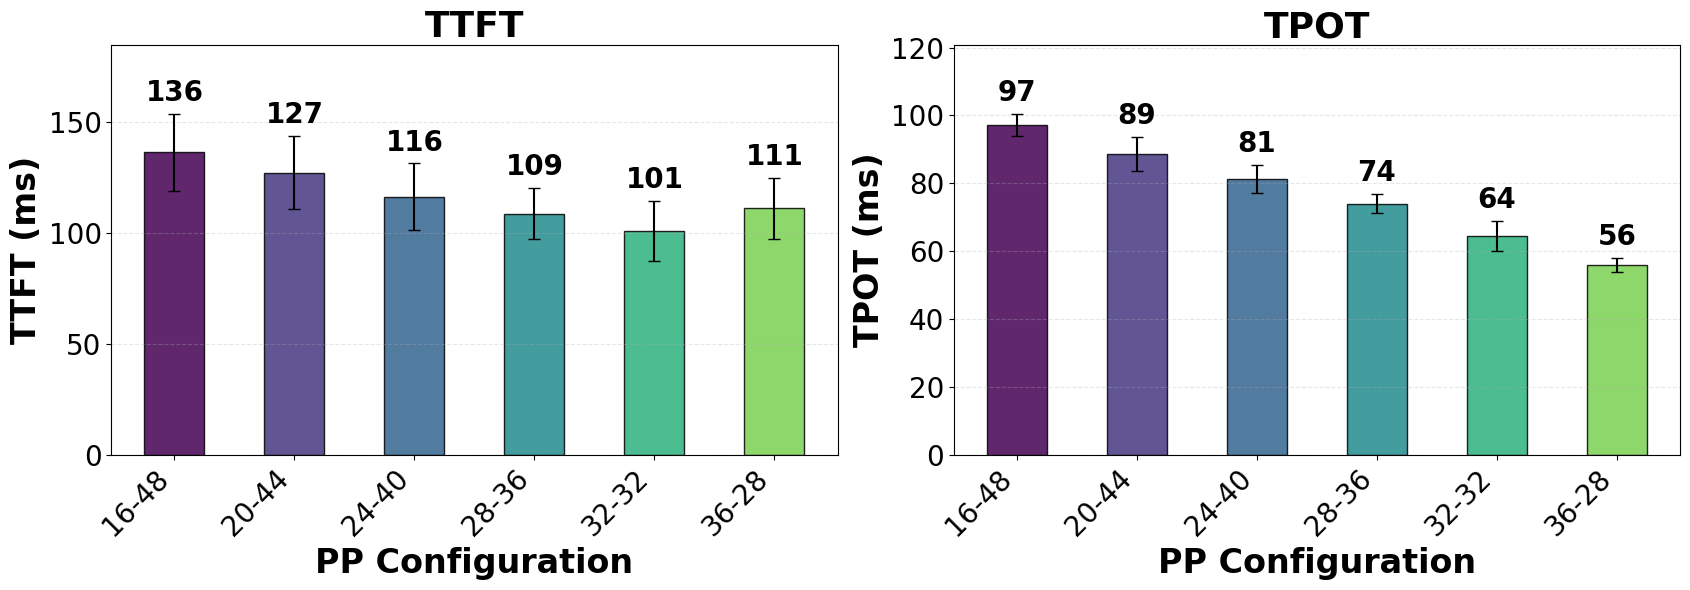


PP Config    TTFT (ms)    TPOT (ms)    Throughput (req/s)   Token Throughput (tok/s) 
-------------------------------------------------------------------------------------
16-48        136.46       97.25        3.88                 248.32                   
20-44        127.27       88.69        3.95                 253.06                   
24-40        116.28       81.26        4.01                 256.79                   
28-36        108.74       74.03        4.07                 260.71                   
32-32        100.91       64.48        4.15                 265.90                   
36-28        111.14       55.94        4.35                 278.57                   

Best configurations:
  - Lowest TTFT: PP=32-32 (100.91ms)
  - Lowest TPOT: PP=36-28 (55.94ms)
  - Highest Throughput: PP=36-28 (4.35 req/s)

Relative to PP=32-32 baseline:
  PP=16-48: TTFT +35.2%, TPOT +50.8%, Throughput -6.5%
  PP=20-44: TTFT +26.1%, TPOT +37.5%, Throughput -4.8%
  PP=24-40: TTFT +15.2%, TPO

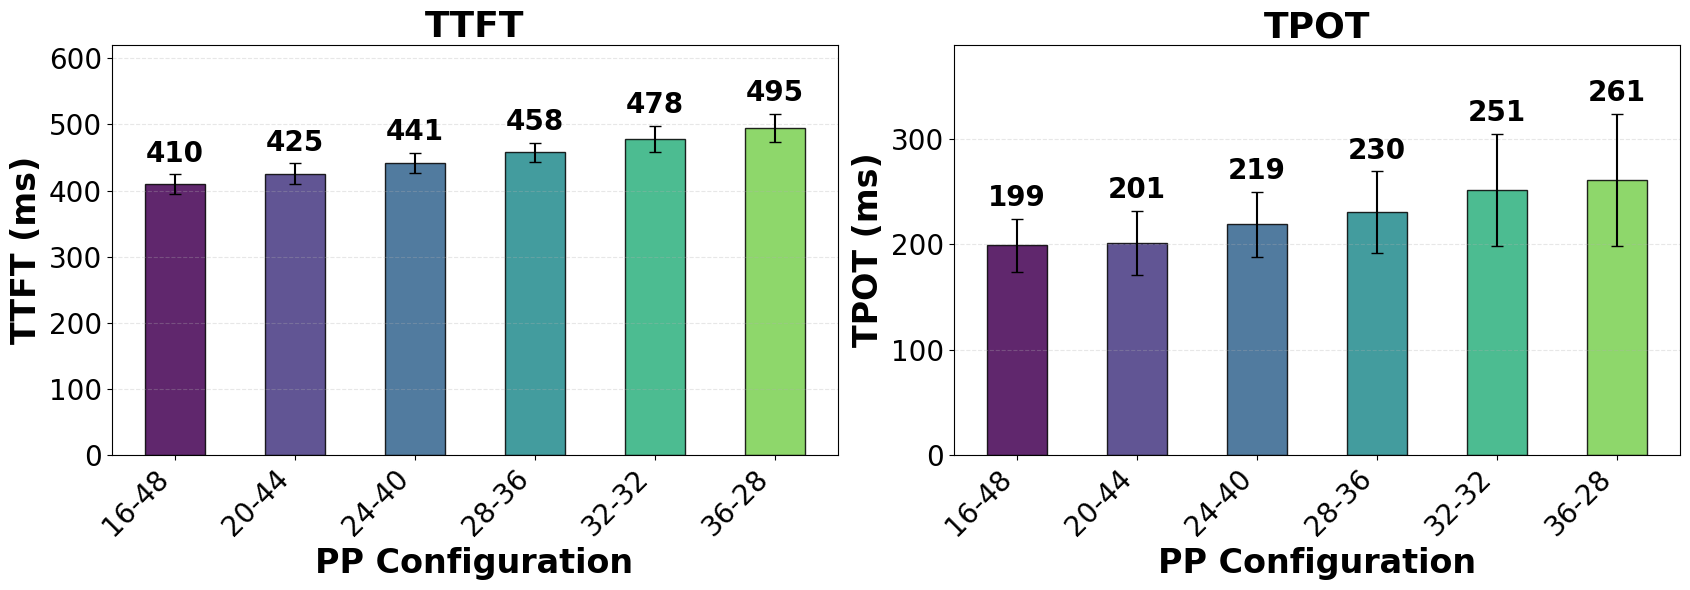


PP Config    TTFT (ms)    TPOT (ms)    Throughput (req/s)   Token Throughput (tok/s) 
-------------------------------------------------------------------------------------
16-48        409.61       198.80       1.95                 31.21                    
20-44        425.28       201.07       1.96                 31.42                    
24-40        441.34       218.74       1.96                 31.32                    
28-36        457.69       230.19       1.96                 31.35                    
32-32        478.18       251.35       1.96                 31.41                    
36-28        494.82       261.03       1.97                 31.45                    

Best configurations:
  - Lowest TTFT: PP=16-48 (409.61ms)
  - Lowest TPOT: PP=16-48 (198.80ms)
  - Highest Throughput: PP=36-28 (1.97 req/s)

Relative to PP=32-32 baseline:
  PP=16-48: TTFT -14.3%, TPOT -20.9%, Throughput -0.5%
  PP=20-44: TTFT -11.1%, TPOT -20.0%, Throughput +0.0%
  PP=24-40: TTFT -7.7%, TPO

In [51]:
# Create comparison charts by PP configuration: TTFT and TPOT
import matplotlib.pyplot as plt
import numpy as np

if len(results_df_1) > 0:
    # ========== FILTER CONFIGURATION ==========
    # Set to None or empty list to include all values
    INPUT_LEN_FILTER = None   # e.g., [512, 1024] or None for all
    OUTPUT_LEN_FILTER = None  # e.g., [16, 64] or None for all
    RR_FILTER = None          # e.g., [2, 5] or None for all
    # ==========================================
    
    # Use directory from Cell 5 config
    current_log_dir = analysis_log_dir_1
    
    # Apply filters
    plot_df = results_df_1.copy()
    
    if INPUT_LEN_FILTER:
        plot_df = plot_df[plot_df['input_len'].isin(INPUT_LEN_FILTER)]
        print(f"Filtering input_len: {INPUT_LEN_FILTER}")
    
    if OUTPUT_LEN_FILTER:
        plot_df = plot_df[plot_df['output_len'].isin(OUTPUT_LEN_FILTER)]
        print(f"Filtering output_len: {OUTPUT_LEN_FILTER}")
    
    if RR_FILTER:
        plot_df = plot_df[plot_df['rr'].isin(RR_FILTER)]
        print(f"Filtering request rate: {RR_FILTER}")
    
    # Group by benchmark config (input_len, output_len, rr) to compare across PP configs
    benchmark_groups = plot_df.groupby(['input_len', 'output_len', 'rr'])
    
    print(f"\nFound {len(benchmark_groups)} benchmark configurations")
    
    for (input_len, output_len, rr), group_df in benchmark_groups:
        print(f"\n{'='*80}")
        print(f"Benchmark: input={input_len}, output={output_len}, rr={rr}")
        print(f"{'='*80}")
        
        # Sort by PP config for consistent ordering
        group_df = group_df.sort_values('pp')
        pp_configs = group_df['pp'].tolist()
        
        if len(pp_configs) < 1:
            print("  No data for this configuration")
            continue
        
        # Create figure with 2 subplots: TTFT, TPOT
        fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
        
        colors = plt.cm.viridis(np.linspace(0, 0.8, len(pp_configs)))
        x = np.arange(len(pp_configs))
        
        # ===== Plot 1: TTFT =====
        ax1 = axes[0]
        # Convert to milliseconds
        ttft_values = group_df['ttft_mean'].values * 1000
        ttft_stds = group_df['ttft_std'].values * 1000
        ttft_ymax = float(np.max(ttft_values + ttft_stds)) if len(ttft_values) else 1.0
        
        bars1 = ax1.bar(x, ttft_values, BAR_WIDTH, yerr=ttft_stds, capsize=4,
                       color=colors, alpha=0.85, edgecolor='black', linewidth=1)
        
        ax1.set_xlabel('PP Configuration', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax1.set_ylabel('TTFT (ms)', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax1.set_title(f'TTFT',
                     fontsize=TITLE_FONTSIZE, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(pp_configs, rotation=45, ha='right', fontsize=TICK_FONTSIZE)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        ax1.set_ylim(0, ttft_ymax * 1.20)
        
        # Add value labels
        for bar, val, std in zip(bars1, ttft_values, ttft_stds):
            label_y = val + (std if std else 0) + ttft_ymax * 0.02
            ax1.text(bar.get_x() + bar.get_width()/2., label_y,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=VALUE_FONTSIZE, fontweight='bold')
        
        # ===== Plot 2: TPOT =====
        ax2 = axes[1]
        # Convert to milliseconds
        tpot_values = group_df['tpot_mean'].values * 1000
        tpot_stds = group_df['tpot_std'].values * 1000
        tpot_ymax = float(np.max(tpot_values + tpot_stds)) if len(tpot_values) else 1.0
        
        bars2 = ax2.bar(x, tpot_values, BAR_WIDTH, yerr=tpot_stds, capsize=4,
                       color=colors, alpha=0.85, edgecolor='black', linewidth=1)
        
        ax2.set_xlabel('PP Configuration', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax2.set_ylabel('TPOT (ms)', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax2.set_title(f'TPOT',
                     fontsize=TITLE_FONTSIZE, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(pp_configs, rotation=45, ha='right', fontsize=TICK_FONTSIZE)
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        ax2.set_ylim(0, tpot_ymax * 1.20)
        
        # Add value labels
        for bar, val, std in zip(bars2, tpot_values, tpot_stds):
            label_y = val + (std if std else 0) + tpot_ymax * 0.02
            ax2.text(bar.get_x() + bar.get_width()/2., label_y,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=VALUE_FONTSIZE, fontweight='bold')
        
        plt.tight_layout()
        
        # Save figure
        save_path = current_log_dir / f'pp_comparison_in{input_len}_out{output_len}_rr{rr}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
        plt.show()
        
        # Print summary table (convert to ms for display)
        print(f"\n{'PP Config':<12} {'TTFT (ms)':<12} {'TPOT (ms)':<12} {'Throughput (req/s)':<20} {'Token Throughput (tok/s)':<25}")
        print("-" * 85)
        for _, row in group_df.iterrows():
            print(f"{row['pp']:<12} {row['ttft_mean']*1000:<12.2f} {row['tpot_mean']*1000:<12.2f} {row['throughput']:<20.2f} {row['output_tokens_throughput']:<25.2f}")
        
        # Find best PP config
        best_ttft_idx = group_df['ttft_mean'].idxmin()
        best_tpot_idx = group_df['tpot_mean'].idxmin()
        best_throughput_idx = group_df['throughput'].idxmax()
        
        print(f"\nBest configurations:")
        print(f"  - Lowest TTFT: PP={group_df.loc[best_ttft_idx, 'pp']} ({group_df.loc[best_ttft_idx, 'ttft_mean']*1000:.2f}ms)")
        print(f"  - Lowest TPOT: PP={group_df.loc[best_tpot_idx, 'pp']} ({group_df.loc[best_tpot_idx, 'tpot_mean']*1000:.2f}ms)")
        print(f"  - Highest Throughput: PP={group_df.loc[best_throughput_idx, 'pp']} ({group_df.loc[best_throughput_idx, 'throughput']:.2f} req/s)")
        
        # Calculate relative improvements compared to baseline (32-32)
        baseline_row = group_df[group_df['pp'] == '32-32']
        if len(baseline_row) > 0:
            baseline_ttft = baseline_row['ttft_mean'].values[0]
            baseline_tpot = baseline_row['tpot_mean'].values[0]
            baseline_throughput = baseline_row['throughput'].values[0]
            
            print(f"\nRelative to PP=32-32 baseline:")
            for _, row in group_df.iterrows():
                if row['pp'] != '32-32':
                    ttft_change = ((row['ttft_mean'] - baseline_ttft) / baseline_ttft) * 100
                    tpot_change = ((row['tpot_mean'] - baseline_tpot) / baseline_tpot) * 100
                    throughput_change = ((row['throughput'] - baseline_throughput) / baseline_throughput) * 100
                    print(f"  PP={row['pp']}: TTFT {ttft_change:+.1f}%, TPOT {tpot_change:+.1f}%, Throughput {throughput_change:+.1f}%")

else:
    print("No data available. Please run the previous cell first.")


Found 1 benchmark configurations

Benchmark: input=64, output=64, rr=5
Plot saved to: /home/bxb1/vllm_workbench/vllm/logs/project-migration_cmp_debug/pp_migration_comparison_in64_out64_rr5.png


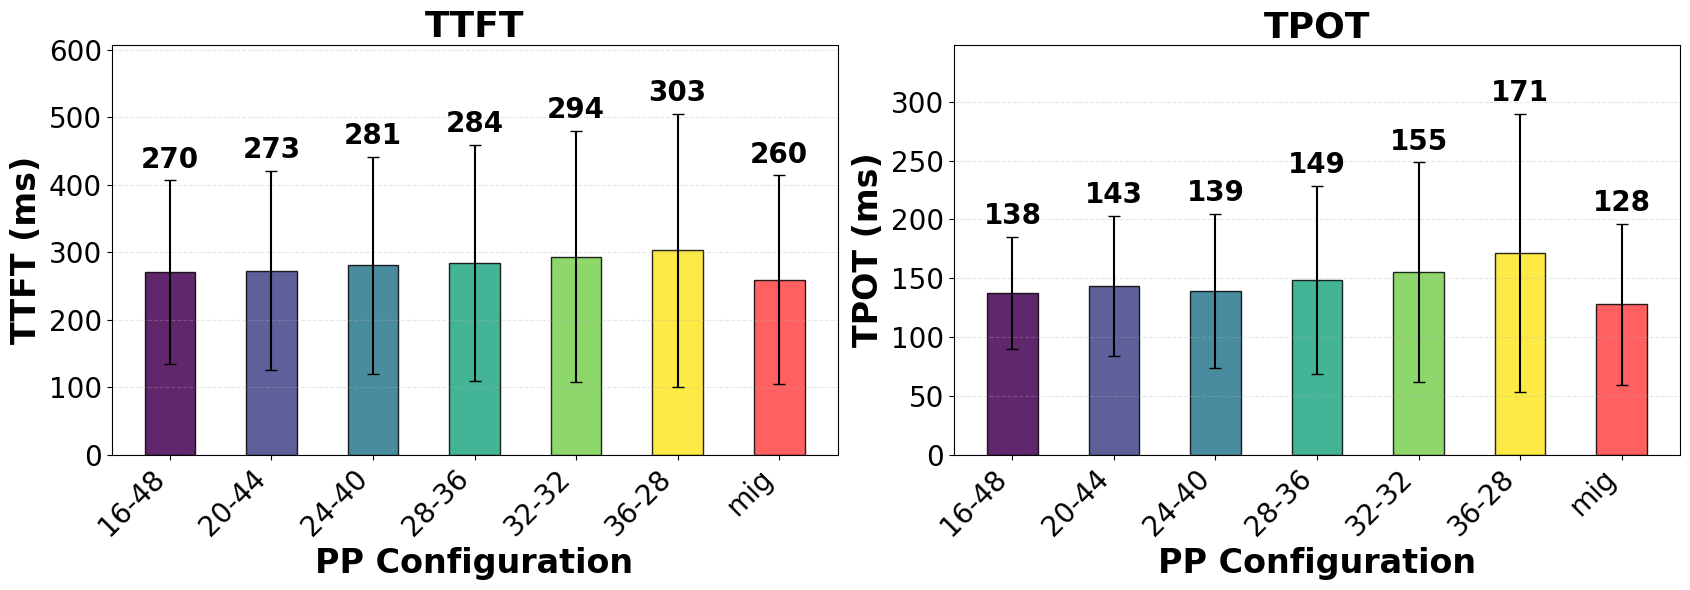


PP Config       Migration    TTFT (ms)    TPOT (ms)    Throughput (req/s)  
---------------------------------------------------------------------------
16-48           No           270.32       137.58       2.58                
20-44           No           272.69       143.47       2.59                
24-40           No           280.53       139.07       2.60                
28-36           No           283.91       148.65       2.63                
32-32           No           293.70       155.00       2.64                
36-28           No           303.34       171.43       2.66                
36-28           Yes          259.69       127.78       2.59                

Migration Impact Analysis:
  Static configs: 6 | Migration configs: 1
  Average TTFT: Static=284.08ms, Migration=259.69ms
  Average TPOT: Static=149.20ms, Migration=127.78ms
  TTFT Impact: -8.6%
  TPOT Impact: -14.4%


In [52]:
# Create comparison charts by PP configuration with Migration indicator
import matplotlib.pyplot as plt
import numpy as np

if len(results_df_2) > 0:
    # ========== FILTER CONFIGURATION ==========
    # Set to None or empty list to include all values
    INPUT_LEN_FILTER = None   # e.g., [512, 1024] or None for all
    OUTPUT_LEN_FILTER = None  # e.g., [16, 64] or None for all
    RR_FILTER = None          # e.g., [2, 5] or None for all
    # ==========================================
    
    # Use directory from Cell 5 config
    current_log_dir = analysis_log_dir_2
    
    # Apply filters
    plot_df = results_df_2.copy()
    plot_df['migration'] = plot_df['mig'].astype(bool)
    
    if INPUT_LEN_FILTER:
        plot_df = plot_df[plot_df['input_len'].isin(INPUT_LEN_FILTER)]
        print(f"Filtering input_len: {INPUT_LEN_FILTER}")
    
    if OUTPUT_LEN_FILTER:
        plot_df = plot_df[plot_df['output_len'].isin(OUTPUT_LEN_FILTER)]
        print(f"Filtering output_len: {OUTPUT_LEN_FILTER}")
    
    if RR_FILTER:
        plot_df = plot_df[plot_df['rr'].isin(RR_FILTER)]
        print(f"Filtering request rate: {RR_FILTER}")
    
    # Group by benchmark config (input_len, output_len, rr) to compare across PP configs
    benchmark_groups = plot_df.groupby(['input_len', 'output_len', 'rr'])
    
    print(f"\nFound {len(benchmark_groups)} benchmark configurations")
    
    for (input_len, output_len, rr), group_df in benchmark_groups:
        print(f"\n{'='*80}")
        print(f"Benchmark: input={input_len}, output={output_len}, rr={rr}")
        print(f"{'='*80}")
        
        # Sort: non-migration first (by pp), then migration configs at the end
        group_df = group_df.sort_values(['migration', 'pp'])
        pp_configs = group_df['pp'].tolist()
        
        if len(pp_configs) < 1:
            print("  No data for this configuration")
            continue
        
        # Create figure with 2 subplots: TTFT, TPOT
        fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
        
        # Color by migration status
        n_static = sum(1 for _, row in group_df.iterrows() if not row['migration'])
        colors = []
        static_idx = 0
        for _, row in group_df.iterrows():
            if row['migration']:
                colors.append(MIGRATION_COLOR)
            else:
                colors.append(plt.cm.viridis(static_idx / max(1, n_static - 1)))
                static_idx += 1
        
        x = np.arange(len(pp_configs))
        
        # Add migration indicator to labels (format: "18-46→36-28" for migration)
        x_labels = []
        for _, row in group_df.iterrows():
            if row['migration']:
                # Parse pp like "36-28" and create label showing migration path
                pp_parts = row['pp'].split('-')
                if len(pp_parts) == 2:
                    # Assume migration from balanced config to this config
                    total = int(pp_parts[0]) + int(pp_parts[1])
                    balanced = f"{total//2}-{total//2}"
                    x_labels.append(f"mig")
                else:
                    x_labels.append(f"{row['pp']}(mig)")
            else:
                x_labels.append(row['pp'])
        
        # ===== Plot 1: TTFT =====
        ax1 = axes[0]
        # Convert to milliseconds
        ttft_values = group_df['ttft_mean'].values * 1000
        ttft_stds = group_df['ttft_std'].values * 1000
        ttft_ymax = float(np.max(ttft_values + ttft_stds)) if len(ttft_values) else 1.0
        
        bars1 = ax1.bar(x, ttft_values, BAR_WIDTH, yerr=ttft_stds, capsize=4,
                       color=colors, alpha=0.85, edgecolor='black', linewidth=1)
        
        ax1.set_xlabel('PP Configuration', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax1.set_ylabel('TTFT (ms)', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax1.set_title(f'TTFT',
                     fontsize=TITLE_FONTSIZE, fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=TICK_FONTSIZE)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        ax1.set_ylim(0, ttft_ymax * 1.20)
        
        # Add value labels
        for bar, val, std in zip(bars1, ttft_values, ttft_stds):
            label_y = val + (std if std else 0) + ttft_ymax * 0.02
            ax1.text(bar.get_x() + bar.get_width()/2., label_y,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=VALUE_FONTSIZE, fontweight='bold')
        
        # ===== Plot 2: TPOT =====
        ax2 = axes[1]
        # Convert to milliseconds
        tpot_values = group_df['tpot_mean'].values * 1000
        tpot_stds = group_df['tpot_std'].values * 1000
        tpot_ymax = float(np.max(tpot_values + tpot_stds)) if len(tpot_values) else 1.0
        
        bars2 = ax2.bar(x, tpot_values, BAR_WIDTH, yerr=tpot_stds, capsize=4,
                       color=colors, alpha=0.85, edgecolor='black', linewidth=1)
        
        ax2.set_xlabel('PP Configuration', fontsize=LABEL_FONTSIZE, fontweight='bold') 
        ax2.set_ylabel('TPOT (ms)', fontsize=LABEL_FONTSIZE, fontweight='bold')
        ax2.set_title(f'TPOT',
                     fontsize=TITLE_FONTSIZE, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=TICK_FONTSIZE)
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        ax2.set_ylim(0, tpot_ymax * 1.20)
        
        # Add value labels
        for bar, val, std in zip(bars2, tpot_values, tpot_stds):
            label_y = val + (std if std else 0) + tpot_ymax * 0.02
            ax2.text(bar.get_x() + bar.get_width()/2., label_y,
                    f'{val:.0f}', ha='center', va='bottom', fontsize=VALUE_FONTSIZE, fontweight='bold')
        
        plt.tight_layout()
        
        # Save figure with migration indicator
        save_path = current_log_dir / f'pp_migration_comparison_in{input_len}_out{output_len}_rr{rr}.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
        plt.show()
        
        # Print summary table with migration indicator (convert to ms for display)
        print(f"\n{'PP Config':<15} {'Migration':<12} {'TTFT (ms)':<12} {'TPOT (ms)':<12} {'Throughput (req/s)':<20}")
        print("-" * 75)
        for _, row in group_df.iterrows():
            mig_status = 'Yes' if row['migration'] else 'No'
            print(f"{row['pp']:<15} {mig_status:<12} {row['ttft_mean']*1000:<12.2f} {row['tpot_mean']*1000:<12.2f} {row['throughput']:<20.2f}")
        
        # Analyze migration impact
        static_configs = group_df[~group_df['migration']]
        migration_configs = group_df[group_df['migration']]
        
        if len(static_configs) > 0 and len(migration_configs) > 0:
            print(f"\nMigration Impact Analysis:")
            print(f"  Static configs: {len(static_configs)} | Migration configs: {len(migration_configs)}")
            
            avg_ttft_static = static_configs['ttft_mean'].mean() * 1000
            avg_ttft_migration = migration_configs['ttft_mean'].mean() * 1000
            avg_tpot_static = static_configs['tpot_mean'].mean() * 1000
            avg_tpot_migration = migration_configs['tpot_mean'].mean() * 1000
            
            print(f"  Average TTFT: Static={avg_ttft_static:.2f}ms, Migration={avg_ttft_migration:.2f}ms")
            print(f"  Average TPOT: Static={avg_tpot_static:.2f}ms, Migration={avg_tpot_migration:.2f}ms")
            
            if avg_ttft_static > 0:
                ttft_impact = ((avg_ttft_migration - avg_ttft_static) / avg_ttft_static) * 100
                print(f"  TTFT Impact: {ttft_impact:+.1f}%")
            
            if avg_tpot_static > 0:
                tpot_impact = ((avg_tpot_migration - avg_tpot_static) / avg_tpot_static) * 100
                print(f"  TPOT Impact: {tpot_impact:+.1f}%")

else:

    print("No data available. Please run the previous cell first.")    